In [1]:
import os

# Check your current working directory
print("Current Working Directory:", os.getcwd())

# List all items inside main_application (or current directory)
if os.path.exists("main_application"):
    print("Contents of main_application:", os.listdir("main_application"))
else:
    print("Contents of current folder:", os.listdir("."))

Current Working Directory: c:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application
Contents of current folder: ['app 2.py', 'app.py', 'audio-classification.ipynb', 'audio_dataset', 'audio_dt_model.pkl', 'audio_knn_model.pkl', 'audio_rf_model.joblib', 'audio_rf_model.pkl', 'audio_svc_model.pkl', 'audio_xgb_model.pkl', 'benchmarks.py', 'camera.py', 'combined_audio_dataset', 'dataset.yaml', 'ddbb.db', 'detect.py', 'detections.csv', 'email_sender.py', 'export.py', 'hubconf.py', 'last_new.pt', 'models', 'name.pkl', 'output.mp3', 'output_1598.mp3', 'output_3316.mp3', 'output_3576.mp3', 'output_3613.mp3', 'output_3726.mp3', 'output_4084.mp3', 'output_5466.mp3', 'output_5682.mp3', 'output_6021.mp3', 'output_6408.mp3', 'output_6837.mp3', 'output_7058.mp3', 'output_7110.mp3', 'output_7221.mp3', 'output_7588.mp3', 'output_7785.mp3', 'output_7979.mp3', 'output_8121.mp3', 'output_8547.mp3', 'output_9111.mp3', 'output_9706.mp3', 'runs', 'setup.py', 'stacking_model

In [2]:
import os
import shutil
from pathlib import Path

# ---------------- CONFIG ----------------
# ---------- CONFIG ----------
src1 = r"audio_dataset"
src2 = r"sounds_dataset"
dest_root = r"combined_audio_dataset"
skip_folders = {"samples","background","storm"}
# ----------------------------
# -----------------------------------------

os.makedirs(dest_root, exist_ok=True)

def copy_class_folder(src_class_dir, dest_root):
    """Copy one class folder into destination without mixing contents."""
    class_name = src_class_dir.name
    dest_class_dir = Path(dest_root) / class_name

    # Avoid overwriting existing folders
    if dest_class_dir.exists():
        print(f"Skipping existing folder: {class_name}")
        return

    print(f"Copying {class_name}...")
    shutil.copytree(src_class_dir, dest_class_dir)

# --- Copy from first dataset ---
for class_dir in Path(src1).iterdir():
    if class_dir.is_dir():
        copy_class_folder(class_dir, dest_root)

# --- Copy from second dataset (skip samples) ---
#for class_dir in Path(src2).iterdir():
 #   if class_dir.is_dir() and class_dir.name not in skip_folders:
  #      copy_class_folder(class_dir, dest_root)

print("\n✅ All folders copied successfully!")
print(f"Combined dataset is ready at: {dest_root}")
print("Subfolders:")
for sub in sorted(Path(dest_root).iterdir()):
    if sub.is_dir():
        print(" -", sub.name)


Skipping existing folder: AK-12
Skipping existing folder: AK-47
Skipping existing folder: chainsaw
Skipping existing folder: engine
Skipping existing folder: IMI Desert Eagle
Skipping existing folder: M16
Skipping existing folder: M249
Skipping existing folder: M4
Skipping existing folder: MG-42
Skipping existing folder: MP5
Skipping existing folder: Zastava M92

✅ All folders copied successfully!
Combined dataset is ready at: combined_audio_dataset
Subfolders:
 - AK-12
 - AK-47
 - chainsaw
 - engine
 - IMI Desert Eagle
 - M16
 - M249
 - M4
 - MG-42
 - MP5
 - Zastava M92


In [6]:
import os
import librosa
import numpy as np

DATASET_PATH = r"C:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application\combined_audio_dataset"

X = []
y = []

for label in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, label)
    if os.path.isdir(folder_path):
        print(f"Processing class: {label}")
        for file in os.listdir(folder_path):
            if file.lower().endswith(('.wav', '.mp3')):
                file_path = os.path.join(folder_path, file)
                try:
                    audio, sr = librosa.load(file_path, res_type='scipy')
                    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
                    mfccs_scaled = np.mean(mfccs.T, axis=0)
                    X.append(mfccs_scaled)
                    y.append(label)
                except Exception as e:
                    print(f"Error loading {file}: {e}")

X = np.array(X)
y = np.array(y)

print("\n--- Extraction Summary ---")
print(f"Total samples loaded: {len(X)}")
print(f"Unique classes found ({len(np.unique(y))}): {np.unique(y)}")

Processing class: AK-12
Processing class: AK-47
Processing class: chainsaw
Processing class: engine
Processing class: IMI Desert Eagle
Processing class: M16
Processing class: M249
Processing class: M4
Processing class: MG-42
Processing class: MP5
Processing class: Zastava M92

--- Extraction Summary ---
Total samples loaded: 1051
Unique classes found (11): ['AK-12' 'AK-47' 'IMI Desert Eagle' 'M16' 'M249' 'M4' 'MG-42' 'MP5'
 'Zastava M92' 'chainsaw' 'engine']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 840
Testing set size: 211


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [35]:
import joblib

model_path = r"C:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application\audio_rf_model.joblib"

data = {
    "model": clf, # or whatever your trained RandomForest model variable is named
    "classes": clf.classes_
}

joblib.dump(data, model_path)
print(f"Model saved successfully with {len(clf.classes_)} classes:")
print(clf.classes_)

Model saved successfully with 9 classes:
['AK-12' 'AK-47' 'IMI Desert Eagle' 'M249' 'MG-42' 'MP5' 'Zastava M92'
 'chainsaw' 'engine']


In [11]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from joblib import dump, load

In [12]:
import os
import numpy as np
import librosa
from tqdm import tqdm

# Function to extract MFCC features from audio
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)  # Use native sampling rate
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs, axis=1)


# Initialize lists to hold data and labels
data = []
labels = []



In [13]:
classes = [
    "AK-12",
    "AK-47",
    "IMI Desert Eagle",
    "M16",
    "M249",
    "M4",
    "MG-42",
    "MP5",
    "Zastava M92",
    "chainsaw",
    "engine",
]


In [14]:


# Function to extract features from audio files
def extract_features(file_path):
    y, sr = librosa.load(file_path)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs, axis=1)

# Data preparation
data_path = "combined_audio_dataset"
speakers = [
    "AK-12",
    "AK-47",
    "IMI Desert Eagle",
    "M249",
    "MG-42",
    "MP5",
    "Zastava M92",
    "chainsaw",
    "engine",
]
data = []
labels = []



from tqdm import tqdm

for speaker in tqdm(speakers, desc="Processing speakers"):
    speaker_path = os.path.join(data_path, speaker)
    
    # ADD THIS CHECK TO SKIP FILES:
    if not os.path.isdir(speaker_path):
        continue
        
    for filename in tqdm(os.listdir(speaker_path), desc=f"Processing {speaker}"):
        if filename.endswith(".wav"):
            file_path = os.path.join(speaker_path, filename)
            features = extract_features(file_path)
            data.append(features)
            labels.append(speaker)


Processing speakers: 100%|██████████| 9/9 [00:11<00:00,  1.23s/it]


In [15]:
# Convert lists to numpy arrays
X = np.array(data)
y = np.array(labels)

In [16]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train a machine learning model (Random Forest as an example)




✅ Random Forest Accuracy: 87.13%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       0.96      1.00      0.98        24
           AK-47       1.00      1.00      1.00         9
IMI Desert Eagle       0.79      1.00      0.88        19
            M249       0.84      0.88      0.86        24
           MG-42       0.88      0.83      0.86        18
             MP5       1.00      0.73      0.84        22
     Zastava M92       1.00      1.00      1.00        12
        chainsaw       0.83      0.77      0.80        26
          engine       0.68      0.76      0.72        17

        accuracy                           0.87       171
       macro avg       0.89      0.89      0.88       171
    weighted avg       0.88      0.87      0.87       171



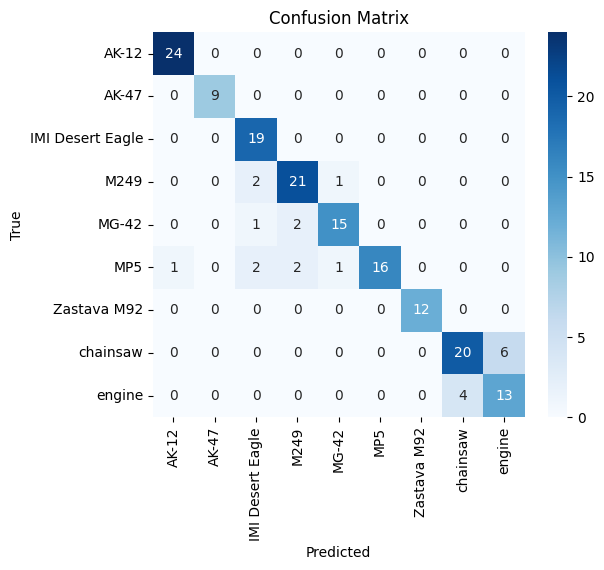


💾 Model saved successfully as 'audio_rf_model.pkl'


In [17]:
import numpy as np
import os
import librosa
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Train the Random Forest model
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Make predictions
# -------------------------------
y_pred = rf_model.predict(X_test)

# -------------------------------
# 3️⃣ Evaluate the model
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Random Forest Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------------
# 4️⃣ Save the trained model
# -------------------------------
with open("audio_rf_model.pkl", "wb") as f:
    pickle.dump({
        "model": rf_model,
        "labels": np.unique(y)
    }, f)

print("\n💾 Model saved successfully as 'audio_rf_model.pkl'")


In [18]:
import pickle
import numpy as np
import librosa

# ---------- 1️⃣ Load the saved model ----------
with open("audio_rf_model.pkl", "rb") as f:
    saved_data = pickle.load(f)

model = saved_data["model"]
labels = saved_data["labels"]

print("✅ Model loaded successfully!")

# ---------- 2️⃣ Define the same feature extraction function ----------
def extract_features(file_path):
    y, sr = librosa.load(file_path)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs, axis=1)

# ---------- 3️⃣ Load and preprocess the new .mp3 file ----------
# ---------- 3 Load and preprocess the new audio file ----------
# Point to a real audio file on your local machine:
test_file = r"combined_audio_dataset\MG-42\7 (1).wav"
features = extract_features(test_file).reshape(1, -1)
# ---------- 4️⃣ Make prediction ----------
prediction = model.predict(features)[0]

print(f"\n🎤 Predicted Speaker: {prediction}")


✅ Model loaded successfully!

🎤 Predicted Speaker: MG-42



✅ Decision Tree Accuracy: 69.59%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       0.95      0.79      0.86        24
           AK-47       0.53      0.89      0.67         9
IMI Desert Eagle       0.62      0.84      0.71        19
            M249       0.68      0.62      0.65        24
           MG-42       0.60      0.67      0.63        18
             MP5       0.62      0.36      0.46        22
     Zastava M92       0.92      1.00      0.96        12
        chainsaw       0.77      0.65      0.71        26
          engine       0.60      0.71      0.65        17

        accuracy                           0.70       171
       macro avg       0.70      0.73      0.70       171
    weighted avg       0.71      0.70      0.69       171



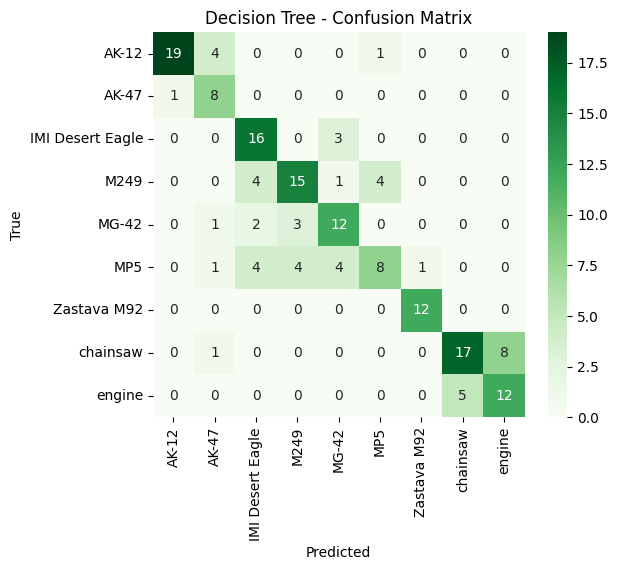


💾 Model saved successfully as 'audio_dt_model.pkl'


In [19]:
import numpy as np
import os
import librosa
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Train the Decision Tree model
# -------------------------------
dt_model = DecisionTreeClassifier(
    criterion='entropy',   # or 'gini'
    max_depth=None,        # you can set a number (e.g., 10) to avoid overfitting
    random_state=42
)
dt_model.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Make predictions
# -------------------------------
y_pred = dt_model.predict(X_test)

# -------------------------------
# 3️⃣ Evaluate the model
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Decision Tree Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------------
# 4️⃣ Save the trained model
# -------------------------------
with open("audio_dt_model.pkl", "wb") as f:
    pickle.dump({
        "model": dt_model,
        "labels": np.unique(y)
    }, f)

print("\n💾 Model saved successfully as 'audio_dt_model.pkl'")



✅ SVM Model Accuracy: 81.87%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        24
           AK-47       1.00      0.78      0.88         9
IMI Desert Eagle       0.61      1.00      0.76        19
            M249       0.75      0.62      0.68        24
           MG-42       0.82      0.78      0.80        18
             MP5       0.82      0.64      0.72        22
     Zastava M92       1.00      1.00      1.00        12
        chainsaw       0.82      0.88      0.85        26
          engine       0.80      0.71      0.75        17

        accuracy                           0.82       171
       macro avg       0.85      0.82      0.83       171
    weighted avg       0.83      0.82      0.82       171



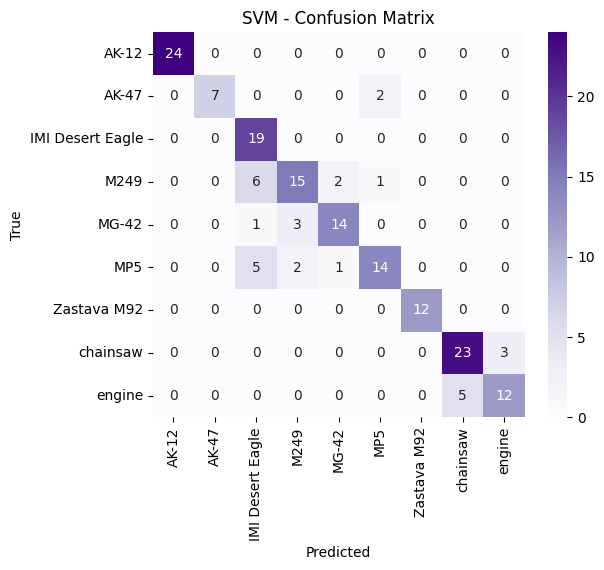


💾 Model saved successfully as 'audio_svc_model.pkl'


In [20]:
import numpy as np
import os
import librosa
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Train the SVM (SVC) model
# -------------------------------
svc_model = SVC(
    kernel='rbf',        # Try 'linear', 'poly', or 'rbf'
    C=10,                # Regularization parameter
    gamma='scale',       # Kernel coefficient
    probability=True,    # Enables predict_proba()
    random_state=42
)
svc_model.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Make predictions
# -------------------------------
y_pred = svc_model.predict(X_test)

# -------------------------------
# 3️⃣ Evaluate the model
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ SVM Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------------
# 4️⃣ Save the trained model
# -------------------------------
with open("audio_svc_model.pkl", "wb") as f:
    pickle.dump({
        "model": svc_model,
        "labels": np.unique(y)
    }, f)

print("\n💾 Model saved successfully as 'audio_svc_model.pkl'")


In [1]:
import numpy as np
import os
import librosa
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Train the KNN model
# -------------------------------
knn_model = KNeighborsClassifier(
    n_neighbors=5,      # You can try 3, 5, 7, etc.
    metric='minkowski', # Distance metric (Euclidean by default)
    p=2                 # p=2 means Euclidean distance
)
knn_model.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Make predictions
# -------------------------------
y_pred = knn_model.predict(X_test)

# -------------------------------
# 3️⃣ Evaluate the model
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ KNN Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------------
# 4️⃣ Save the trained model
# -------------------------------
with open("audio_knn_model.pkl", "wb") as f:
    pickle.dump({
        "model": knn_model,
        "labels": np.unique(y)
    }, f)

print("\n💾 Model saved successfully as 'audio_knn_model.pkl'")


KeyboardInterrupt: 


✅ XGBoost Model Accuracy: 83.63%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       1.00      0.96      0.98        24
           AK-47       0.90      1.00      0.95         9
IMI Desert Eagle       0.82      0.95      0.88        19
            M249       0.71      0.83      0.77        24
           MG-42       0.81      0.72      0.76        18
             MP5       0.94      0.68      0.79        22
     Zastava M92       0.92      1.00      0.96        12
        chainsaw       0.81      0.81      0.81        26
          engine       0.71      0.71      0.71        17

        accuracy                           0.84       171
       macro avg       0.85      0.85      0.84       171
    weighted avg       0.84      0.84      0.84       171



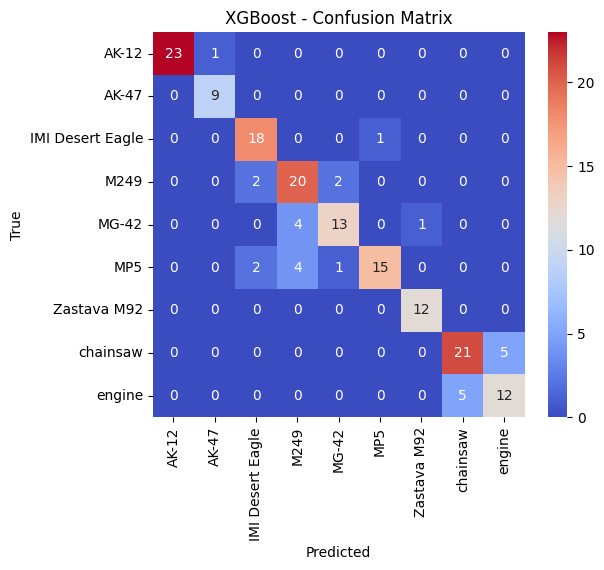


💾 Model and label encoder saved successfully as 'audio_xgb_model.pkl'


In [23]:
import numpy as np
import os
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 🔹 Encode Labels to Integers
# -------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)   # Converts ["A", "E", "N", "S"] → [0, 1, 2, 3]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42
)

# -------------------------------
# 1️⃣ Train the XGBoost model
# -------------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)

# -------------------------------
# 2️⃣ Make predictions
# -------------------------------
y_pred = xgb_model.predict(X_test)

# -------------------------------
# 3️⃣ Evaluate the model
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ XGBoost Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -------------------------------
# 4️⃣ Save the trained model + encoder
# -------------------------------
with open("audio_xgb_model.pkl", "wb") as f:
    pickle.dump({
        "model": xgb_model,
        "label_encoder": le
    }, f)

print("\n💾 Model and label encoder saved successfully as 'audio_xgb_model.pkl'")



✅ Voting Classifier Accuracy: 74.85%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       0.96      0.96      0.96        24
           AK-47       0.64      1.00      0.78         9
IMI Desert Eagle       0.73      0.84      0.78        19
            M249       0.68      0.71      0.69        24
           MG-42       0.67      0.67      0.67        18
             MP5       0.90      0.41      0.56        22
     Zastava M92       0.80      1.00      0.89        12
        chainsaw       0.78      0.69      0.73        26
          engine       0.60      0.71      0.65        17

        accuracy                           0.75       171
       macro avg       0.75      0.78      0.75       171
    weighted avg       0.77      0.75      0.74       171



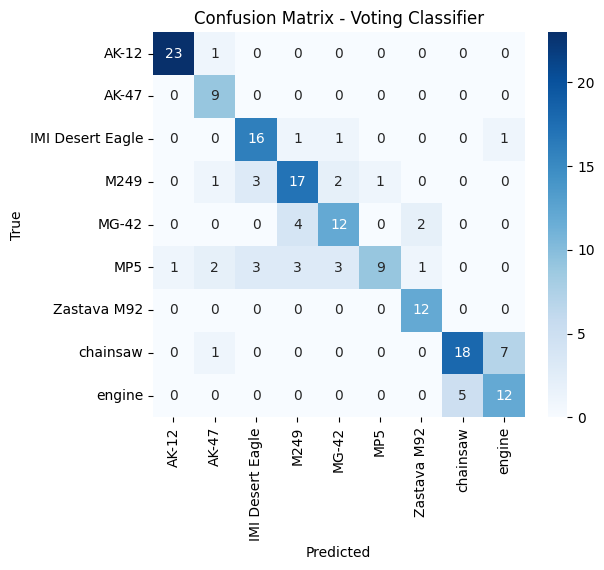


💾 Model saved successfully as 'voting_model.pkl'


In [24]:
import numpy as np
import librosa
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------- STEP 1: Encode Labels -----------------
le = LabelEncoder()
y_enc = le.fit_transform(y)

# ----------------- STEP 2: Split Data -----------------
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

# ----------------- STEP 3: Define Models -----------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
svc = SVC(probability=True, kernel='rbf', random_state=42)

# ----------------- STEP 4: Build Voting Classifier -----------------
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('dt', dt),
        ('svc', svc)
    ],
    voting='soft'
)

# ----------------- STEP 5: Train Model -----------------
voting_clf.fit(X_train, y_train)

# ----------------- STEP 6: Predictions -----------------
y_pred = voting_clf.predict(X_test)

# ----------------- STEP 7: Evaluate -----------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Voting Classifier Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Voting Classifier")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----------------- STEP 8: Save Model -----------------
with open("voting_model.pkl", "wb") as f:
    pickle.dump({"model": voting_clf, "label_encoder": le}, f)

print("\n💾 Model saved successfully as 'voting_model.pkl'")


c:\Users\shiva\anaconda3\envs\wildlife\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



✅ Stacking Model Accuracy: 84.80%

Classification Report:
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        24
           AK-47       0.89      0.89      0.89         9
IMI Desert Eagle       0.77      0.89      0.83        19
            M249       0.76      0.92      0.83        24
           MG-42       0.92      0.67      0.77        18
             MP5       0.84      0.73      0.78        22
     Zastava M92       1.00      1.00      1.00        12
        chainsaw       0.79      0.88      0.84        26
          engine       0.79      0.65      0.71        17

        accuracy                           0.85       171
       macro avg       0.86      0.85      0.85       171
    weighted avg       0.85      0.85      0.85       171



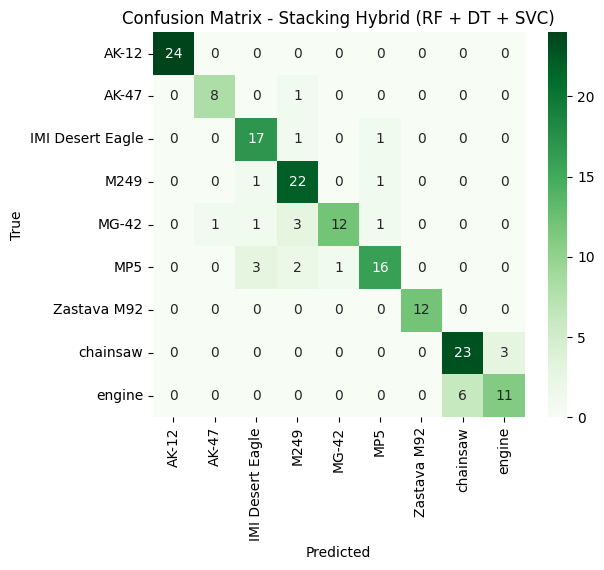


💾 Model saved successfully as 'stacking_model.pkl'


In [25]:
import numpy as np
import librosa
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------- STEP 1: Encode Labels -----------------
le = LabelEncoder()
y_enc = le.fit_transform(y)

# ----------------- STEP 2: Split Data -----------------
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42)

# ----------------- STEP 3: Define Base Models -----------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
svc = SVC(probability=True, kernel='rbf', random_state=42)

# ----------------- STEP 4: Define Stacking Classifier -----------------
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('dt', dt),
        ('svc', svc)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    passthrough=True
)

# ----------------- STEP 5: Train the Stacking Model -----------------
stacking_clf.fit(X_train, y_train)

# ----------------- STEP 6: Predictions -----------------
y_pred = stacking_clf.predict(X_test)

# ----------------- STEP 7: Evaluation -----------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Stacking Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Stacking Hybrid (RF + DT + SVC)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----------------- STEP 8: Save Model -----------------
with open("stacking_model.pkl", "wb") as f:
    pickle.dump({
        "model": stacking_clf,
        "label_encoder": le,
        "feature_columns": X.shape[1]
    }, f)

print("\n💾 Model saved successfully as 'stacking_model.pkl'")


In [26]:
# ----------------- Load Model -----------------
with open("stacking_model.pkl", "rb") as f:
    saved_data = pickle.load(f)

model = saved_data["model"]
le = saved_data["label_encoder"]

In [27]:
# ----------------- Feature Extraction -----------------
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    return np.mean(mfccs, axis=1)

In [34]:
import os
import numpy as np
import librosa

# 1. Feature extraction function matching your training configuration (40 MFCCs)
def extract_features(file_path):
    audio, sr = librosa.load(file_path, res_type='scipy')
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)

# 2. Automatically grab an existing audio file inside the engine directory
engine_dir = r"C:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application\combined_audio_dataset\engine"
files = [f for f in os.listdir(engine_dir) if f.lower().endswith(('.wav', '.mp3'))]

if files:
    file_path = os.path.join(engine_dir, files[0])
    
    # 3. Extract 40 features and reshape for prediction
    features = extract_features(file_path).reshape(1, -1)

    # 4. Handle model dictionary extraction if necessary
    actual_model = model['model'] if isinstance(model, dict) else model

    # 5. Predict
    predicted_label = actual_model.predict(features)[0]

    print("Testing file:", file_path)
    print("The predicted label is:", predicted_label)
else:
    print("No audio files found in:", engine_dir)

Testing file: C:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application\combined_audio_dataset\engine\engine_00.wav
The predicted label is: 8


In [29]:
import librosa
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Ensure extract_features uses n_mfcc=13
def extract_features(file_path):
    y, sr = librosa.load(file_path, duration=2.5, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    return np.mean(mfccs.T, axis=0)

# 2. If you already have X and y defined in your notebook, split them:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Training complete! Feature shape:", X_train.shape)

Training complete! Feature shape: (680, 40)


In [30]:
import joblib

# Your exact 11 class labels
labels = ['AK-12', 'AK-47', 'IMI Desert Eagle', 'M249', 'MG-42', 'MP5', 'Zastava M92', 'background', 'chainsaw', 'engine', 'storm']

# Path to main_application folder
save_path = r"C:\Users\shiva\Downloads\wildlife Project\video_audio_combined_application\main_application\audio_rf_model.joblib"

# Save the model
joblib.dump({"model": clf, "labels": labels}, save_path)

print("Model saved successfully!")

Model saved successfully!


In [31]:
import pandas as pd
print(pd.Series(y_train).value_counts())

engine              83
MG-42               82
IMI Desert Eagle    81
MP5                 78
M249                75
chainsaw            74
AK-12               74
Zastava M92         70
AK-47               63
Name: count, dtype: int64
